# Extreme drought stress provides an ecological benchmark for high-resolution available water capacity maps of Swiss forest soils
by Colin Bloom, Katrin Meusburger, Lorenz Walthert, and Andri Baltensweiler

*This Jupyter Notebook runs the full analysis workflow. Run it from the `notebooks/` directory of this repository (paths below are relative to that location).*

Generally each step should be run sequentially, but it is possible to pre-run steps 0, 1, and 2 before plotting figures. If these PTF steps are pre-run, make sure to re-run the first two cells before skipping.

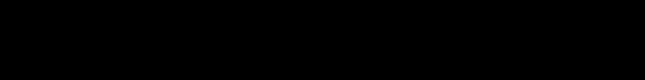

### Environment Setup 
*Note: This cell must be run before any other cell*

In [ ]:
import os
import sys
import pickle
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from IPython.display import Image, display

sys.path.append(os.path.abspath('..'))

from src.retrieve_envidat_data import download_from_envidat
from src.compare_awc_distributions import make_boxplot
from src.combine_awc import combine_awc_by_ptf
from src.national_stats import load_stats, update_stats
from src.plot_ptf_averages import plot_mean_proportion_over_dates, print_pixel_totals_by_month, load_global_stats
from src.plot_ptf_individual import plot_proportion_histogram_standardized, process_depth_scales, build_ptf_boxplot_grid
from src.dsi import run_dsi_pipeline, summarize_run, write_aggregate_summary
from src.model_application import apply_dsi_to_years, YearSpec
from src.discoch_overview import compute_hex_discoloration
from src.seasonal_climate import calculate_seasonal_meteo, calculate_baseline_climatology, calculate_seasonal_anomaly

from src.utils import load_soil_data_cube, mvg_theta, export_awc, scale_directory
from src.ptfs.saxton_and_rawls import apply_saxton_rawls
from src.ptfs.toth import apply_toth
from src.ptfs.zhang_and_schaap import apply_zhang_schaap
from src.ptfs.wosten import apply_wosten
from src.ptfs.weynants import apply_weynants
from src.ptfs.puhlmann import apply_puhlmann
from src.ptfs.teepe import apply_teepe
from src.ptfs.schoch import apply_schoch
from src.ptfs.wessolek import apply_wessolek, get_ka5_int


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)

# Reset to the standard light theme for plots
plt.style.use('default')

# Explicitly force figures to white:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

### User defined parameters 
*Note: This cell must be run before skipping any other cells below*

In [ ]:
# Define where to save the downloaded data
soil_data_dir = "../data/swiss_soil_maps"
disco_data_dir = "../data/swiss_disco_maps"  # Data available upon request of the corresponding author
climate_data_dir = "../data/swiss_climate_maps" # Data available upon request of the corresponding author

# Define output directory
output_dir = "../output"

# Define the matric potential thresholds
PSI_FC_CM = 330  # Field Capacity
PSI_PWP_CM = 16000  # Permanent Wilting Point

# Location of Wessolek parameters
wesso_mvg_loc = '../data/wessolek_MVG_tab10.csv'

# Location of raw meteo data
daily_meteo_loc = {
    "pr": r"../data/daily_meteotest/pr",
    "tas": r"../data/daily_meteotest/tas",
    "tasmax": r"../data/daily_meteotest/tasmax",
    "td": r"../data/daily_meteotest/td",
}

### Required datasets
*Note: Discoloration data is available from the corresponding author upon request. Meteorological data must be requested from Meteotest, however, the corresponding author can provide specific data for peer reviewers to reproduce the analysis upon request.*

In [ ]:
# Create directories in the data folder if they do not already exist
os.makedirs(soil_data_dir, exist_ok=True)
os.makedirs(climate_data_dir, exist_ok=True)
os.makedirs(disco_data_dir, exist_ok=True)

# Download the soil data direct from EnviDat
download_from_envidat(output_dir=soil_data_dir,
                      target_maps=["clay_maps",
                                   "sand_maps",
                                   "gravel_maps",
                                   "density_maps",
                                   "soc_maps",
                                   "depth_map"
                                  ],
                      package_id="soil-property-maps-for-the-swiss-forest"
                     )

# Calculate Meteo Variables
TARGET_YEARS = [2017, 2018, 2019, 2020, 2021, 2022]

calculate_seasonal_meteo(daily_meteo_loc, climate_data_dir, TARGET_YEARS)

### Discoloration Hexagons *(Figure 1)*
*Note: This code produces the hexagons presented in Figure 1 as a shapefile. Map production was done manually in ArcGIS.*

In [ ]:
# Create directories in the output folder if they do not already exist
hex_dir = os.path.join(output_dir, "disco_hex")
os.makedirs(hex_dir, exist_ok=True)

compute_hex_discoloration(
        in_raster_path=os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif'),
        out_hex_path=os.path.join(hex_dir, "hex_discoloration_proportion_3km.shp"),
        boundary_path=None,
        threshold=4000,
        hex_area_km2=3,
        target_crs_epsg=2056,
    )

### Run PTFs on Soil Maps

***Load soil data***

In [ ]:
soil_names = {
    "sand": "sand",  # proportion of fine soil (%)
    "clay": "clay",  # proportion of fine soil (%)
    "gravel": "gravel",  # proportion of soil (%)
    "trd": "density",  # bulk density (g/cm3)
    "soc": "soc",  # organic carbon (%)
    "mrd": "depth"  # rooting depth (cm)
}
depth_ranges = ["0_5", "5_15", "15_30", "30_60", "60_100", "100_200"]

# Load the soil data
ds = load_soil_data_cube(soil_data_dir, depth_ranges, soil_names, load_mrd=False)
print("Loaded soil data cube")

***MvG Regression PTFs***

*Note: PTF of Zhang and Schaap, 2017 requires deep learning model application which is much more computationally expensive than other PTFs. The function is batched and this may need to be optimized based on the individual machine.*

In [ ]:
# Setup output directory
os.makedirs(output_dir, exist_ok=True)
output_awc = os.path.join(output_dir, 'awc')
os.makedirs(output_awc, exist_ok=True)

# Regression PTFs
ptfs = ['schoch', 'teepe', 'wosten', 'weynants', 'puhlmann', 'zhang_and_schaap']

# Apply the pedotransfer functions
for ptf in ptfs:

    if ptf == 'puhlmann':
        ds_applied = apply_puhlmann(ds)
        logging.info("Puhlmann PTF applied")

    elif ptf == 'zhang_and_schaap':
        ds_applied = apply_zhang_schaap(ds)
        logging.info("Zhang and Schaap PTF applied")

    elif ptf == 'wosten':
        ds_applied = apply_wosten(ds)
        logging.info("Wösten PTF applied")

    elif ptf == 'weynants':
        ds_applied = apply_weynants(ds)
        logging.info("Weynants PTF applied")

    elif ptf == 'teepe':
        ds_applied = apply_teepe(ds, awc_direct=False)
        logging.info("Teepe PTF applied")

    elif ptf == 'schoch':
        ds_applied = apply_schoch(ds)
        logging.info("Schoch PTF applied")

    else:
        logging.warning(f"{ptf} is not a valid MvG Regression PTF. Check the desired PTF list  (Table 1)")
        continue

    # Pickle the enriched ds after each PTF
    ptf_pickle = os.path.join(output_awc, f"ds_{ptf}.pkl")
    with open(ptf_pickle, "wb") as f:
        pickle.dump(ds_applied, f, protocol=pickle.HIGHEST_PROTOCOL)
    logging.info(f"Pickled enriched ds → {ptf_pickle}")

    # Calculate FC/PWP and AWC
    ds_applied["fc_vol"] = mvg_theta(PSI_FC_CM, ds_applied["ths"], ds_applied["thr"], ds_applied["alpha"], ds_applied["n"])
    ds_applied["pwp_vol"] = mvg_theta(PSI_PWP_CM, ds_applied["ths"], ds_applied["thr"], ds_applied["alpha"], ds_applied["n"])
    ds_applied["awc_vol"] = (ds_applied["fc_vol"] - ds_applied["pwp_vol"])

    # Export as maps
    export_awc(ds_applied, None, ptf, output_dir=output_awc)

    ds_applied = None

***MvG Classification PTF***

In [ ]:
# Setup output directory if it does not already exist
os.makedirs(output_dir, exist_ok=True)
output_awc = os.path.join(output_dir, 'awc')
os.makedirs(output_awc, exist_ok=True)

ds_applied = ds.copy()

# Calculate Texture
ds_applied['silt'] = 100 - (ds_applied['sand'] + ds_applied['clay'])
ds_applied['Ka5'] = get_ka5_int(ds_applied)
logging.info("Calculated soil texture Ka5")

# Apply Wessolek PTF
ds_applied = apply_wessolek(ds_applied, wesso_mvg_loc)
logging.info("Wessolek PTF applied")

ptf_pickle = os.path.join(output_awc, "ds_wessolek.pkl")
with open(ptf_pickle, "wb") as f:
    pickle.dump(ds_applied, f, protocol=pickle.HIGHEST_PROTOCOL)
logging.info(f"Pickled enriched ds → {ptf_pickle}")

# Calculate FC/PWP and AWC
ds_applied["fc_vol"] = mvg_theta(PSI_FC_CM, ds_applied["ths"], ds_applied["thr"], ds_applied["alpha"], ds_applied["n"])
ds_applied["pwp_vol"] = mvg_theta(PSI_PWP_CM, ds_applied["ths"], ds_applied["thr"], ds_applied["alpha"], ds_applied["n"])
ds_applied["awc_vol"] = (ds_applied["fc_vol"] - ds_applied["pwp_vol"])

# Export as maps
export_awc(ds_applied, None, 'wessolek', output_dir=output_awc)

***Direct FC/PWP PTFs***

*Note: The PTF of Szabó et al. (2021) requires a native R model output. To avoid a complex implementation, the R script found in src/ptfs should simply be run independently for this PTF. Be sure to update the relevant input and output locations in this script before implementation.*

In [ ]:
# Setup output directory if it does not already exist
os.makedirs(output_dir, exist_ok=True)
output_awc = os.path.join(output_dir, 'awc')
os.makedirs(output_awc, exist_ok=True)

# Direct FC/PWP PTFs
ptfs = ['saxton_and_rawls', 'toth']  # szabo is a standalone R script which is necessary to call the original models. Find it in the src/ptfs folder.

# Apply the pedotransfer functions
for ptf in ptfs:
    if ptf == 'saxton_and_rawls':
        ds_applied = apply_saxton_rawls(ds)
        logging.info("Saxton & Rawls PTF applied")

    elif ptf == 'toth':
        ds_applied = apply_toth(ds)
        logging.info("Tóth PTF applied")

    elif ptf == 'szabo':
        logging.info("Szabo et al. PTF is only available as an R script - be sure to update output directories in the script when you run it")
        continue

    else:
        logging.warning(f"{ptf} is not a valid FC/PWP or AWC direct PTF. Check the desired PTF list (Table 1)")
        continue

    # Pickle the enriched ds after each PTF
    ptf_pickle = os.path.join(output_awc, f"ds_{ptf}.pkl")
    with open(ptf_pickle, "wb") as f:
        pickle.dump(ds_applied, f, protocol=pickle.HIGHEST_PROTOCOL)
    logging.info(f"Pickled enriched ds → {ptf_pickle}")

    # Export as maps
    export_awc(ds_applied, None, ptf, output_dir=output_awc)

    ds_applied = None

### Compare PTF distributions *(Figure 2)*

In [ ]:
PTFs = [
    "wessolek",
    "puhlmann",
    "saxton_and_rawls",
    "schoch",
    "szabo",
    "toth",
    "teepe",
    "weynants",
    "wosten",
    "zhang_and_schaap",
]

DEPTHS = ["1m", "2m"]

DEPTH_LABELS = {"1m": "1 m", "2m": "2 m"}

# Find and create input directory
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")

fig, axes = plt.subplots(
    len(DEPTHS), 1, figsize=(7, 4 * len(DEPTHS)), sharex=True, squeeze=False
)

for ax, depth in zip(axes.flat, DEPTHS):
    print(f"Processing depth: {depth}")
    make_boxplot(output_awc, depth, PTFs, ax)

    labels = [label.get_text().title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, fontsize=12, rotation=315, ha="left")


# Reserve space at the top for the legend
plt.tight_layout(rect=[0, 0, 1, 0.95])

legend_elements = [
    Line2D([0], [0], color="gray", linestyle="--", lw=1.5, label="Overall Mean"),
    mpatches.Patch(facecolor="gray", alpha=0.15, label="Overall ±1 SD"),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.99),
    ncol=2,
    frameon=False,
    fontsize=12,
)

out_path = os.path.join(output_dir, "Fig_2.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")

print("Figure 2")
plt.show()

### Discoloration in bins of average AWC with Quartiles *(Figure 3)*

***Calculate PTF/Discoloration Statistics***

In [ ]:
# Define data to process
dates = ['2018-06-30', '2018-07-30', '2018-08-29', '2018-09-28']
disco_threshold = 4000
depths = ['1m', '2m']
datasets = ['szabo', 'weynants', 'puhlmann', 'toth', 'wessolek', 'teepe', 'wosten', 'saxton_and_rawls', 'schoch', 'zhang_and_schaap']

# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_10ptf = os.path.join(output_dir, "ten_ptf_average")
os.makedirs(output_10ptf, exist_ok=True)

# Calculate statistics
stats_path = os.path.join(output_10ptf, "awc_stats.pkl")

if os.path.exists(stats_path):
    existing_stats = load_stats(stats_path)
else:
    existing_stats = []

all_stats = update_stats(
    existing=existing_stats,
    new_datasets=datasets,
    new_depths=depths,
    new_disco_dates=dates,
    awc_input=output_awc,
    disco_input= disco_data_dir,
    output=output_10ptf,
    disco_threshold=disco_threshold,
    stats_path=stats_path,
)

***Plot Average PTF AWC***

In [ ]:
try:
    all_stats = load_global_stats(stats_path)
except FileNotFoundError:
    logging.error(f"Could not find {stats_path}.")
    exit()

ptfs_to_exclude = []

if ptfs_to_exclude:
    # Filter out records where the dataset name is in the exclusion list
    all_stats = [r for r in all_stats if r.get("dataset") not in ptfs_to_exclude]
    logging.info(f"Excluded {ptfs_to_exclude}. {len(all_stats)} records remaining.")

for depth in depths:
    plot_mean_proportion_over_dates(
        records=all_stats,
        depth=depth,
        n_bins=25,
        min_pixels=100,
        show_quartiles=True,
        output_dir=output_10ptf,
        label_bars=False
    )

print_pixel_totals_by_month(all_stats)

### Discoloration in bins of individual PTF AWC *(Figure 4)*
*Note: If you have not already done so, run ***Calculate PTF/Discoloration Statistics****

In [ ]:
# Find and create input and output directories
output_10ptf_indv = os.path.join(output_dir, "individual_ptf")
os.makedirs(output_10ptf_indv, exist_ok=True)

dates = ['2018-09-28']

try:
    all_stats = load_global_stats(stats_path)
except FileNotFoundError:
    logging.error(f"Could not find {stats_path}.")
    exit()

n_bins_config = 25
min_pixels_config = 50

for depth in depths:
    logging.info(f"Calculating uniform scales and global bins for depth: {depth}")

    global_bins, shared_ylim = process_depth_scales(
        records=all_stats,
        depth=depth,
        datasets=datasets,
        dates=dates,
        n_bins=n_bins_config,
        min_pixels=min_pixels_config
    )

    if global_bins is None:
        continue

    logging.info(f"  --> Layout ready. Drawing plots for depth '{depth}'")
    for date in dates:
        for dataset in datasets:
            plot_proportion_histogram_standardized(
                all_stats,
                dataset=dataset,
                depth=depth,
                disco_date=date,
                bins=global_bins,
                ylim=1,
                min_pixels=min_pixels_config,
                show_regression=False,
                show_quartiles=False,
                vertical_fraction_labels=False,
                output_path=os.path.join(output_10ptf_indv, f"proportion_{dataset}_{depth}_{date}.png")
            )

print("Figure 4")
build_ptf_boxplot_grid(
    image_dir=output_10ptf_indv,
    group_order=('1m', '2m'),
    column_headers={'1m': '1 m', '2m': '2 m'},
    output_filename=os.path.join(output_dir, 'Fig_4.png')
)

### Logistic regression fits to AWC *(Figure 5, Table S1)*

In [ ]:
# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_fits = os.path.join(output_dir, 'awc_fits')
os.makedirs(output_fits, exist_ok=True)

months = [9]
ptfs = ["toth", "szabo", "teepe", "wosten", "weynants", "zhang_and_schaap", "saxton_and_rawls", "schoch",
        "wessolek", "puhlmann"]
depths = ["1m", "2m"]


# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_awc, fr"awc_{depth}_{ptf}.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_fits, fr"awc_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[],
                    extra_labels=[],
                    extra_units=[],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_fits)

# Figure 5
print("Figure 5")
display(Image(filename=os.path.join(output_fits, r'awc_wosten_1m_2018_fit/pooled_oof_calibration.png')))
display(Image(filename=os.path.join(output_fits, r'awc_wosten_2m_2018_fit/pooled_oof_calibration.png')))

### Logistic regression fits to AWC, precipitation, and temperature *(Figure 6, Table S2)*

In [ ]:
# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_precip_fits = os.path.join(output_dir, 'awc_precip_temp_fits')
os.makedirs(output_precip_fits, exist_ok=True)

months = [9]
ptfs = ["toth", "szabo", "teepe", "wosten", "weynants", "zhang_and_schaap", "saxton_and_rawls", "schoch",
        "wessolek", "puhlmann"]
depths = ["1m", "2m"]

# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_awc, fr"awc_{depth}_{ptf}.tif")
            PRECIP_PATH = os.path.join(climate_data_dir, "pr_2018_DJFMAM.tif")
            TEMP_PATH = os.path.join(climate_data_dir, "tas_2018_JJA.tif")
            MAX_TEMP_PATH = os.path.join(climate_data_dir, "tasmax_2018_JJA.tif")
            VPD_PATH = os.path.join(climate_data_dir, "vpd_2018_JJA.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_precip_fits, fr"awc_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[PRECIP_PATH, TEMP_PATH],
                    extra_labels=['Precipitation', 'Temperature'],
                    extra_units=['mm', 'degC'],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_precip_fits)

# Figure 6
print("Figure 6")
display(Image(filename=os.path.join(output_precip_fits, r'awc_wosten_1m_2018_fit/pooled_oof_calibration.png')))
display(Image(filename=os.path.join(output_precip_fits, r'awc_wosten_2m_2018_fit/pooled_oof_calibration.png')))

### Calculate optimized AWC Maps *(Figure 8)*

In [ ]:
# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_opt = os.path.join(output_dir, 'optimized_awc')
os.makedirs(output_opt, exist_ok=True)

combine_awc_by_ptf(
    input_dir=output_awc,
    output_dir=output_opt,
    ptfs=["wosten", "szabo", "toth", "teepe"],
)

### Plot fit and histograms for optimized AWC *(Figure A1)*

***AWC Fit***

In [ ]:
# Find and create input and output directories
output_opt = output_opt if "output_opt" in dir() else os.path.join(output_dir, "optimized_awc")
output_4ptf_fits = os.path.join(output_dir, "optimized_ptf_fits")
os.makedirs(output_4ptf_fits, exist_ok=True)

months = [9]

ptfs = ["mean"]
depths = ["1m", "2m"]

# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_opt, fr"awc_{depth}_{ptf}.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_4ptf_fits, fr"awc_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[],
                    extra_labels=[],
                    extra_units=[],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_4ptf_fits)

# Figure A1a
print("Figure A1a")
display(Image(filename=os.path.join(output_4ptf_fits, r'awc_mean_1m_2018_fit/pooled_oof_calibration.png')))
display(Image(filename=os.path.join(output_4ptf_fits, r'awc_mean_2m_2018_fit/pooled_oof_calibration.png')))

***AWC Precipitation Temperature Fit***

In [ ]:
# Find and create input and output directories
output_opt = output_opt if "output_opt" in dir() else os.path.join(output_dir, "optimized_awc")
output_4ptf_fits = os.path.join(output_dir, "optimized_ptf_fits")
os.makedirs(output_4ptf_fits, exist_ok=True)

months = [9]

ptfs = ["mean"]
depths = ["1m", "2m"]

# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_opt, fr"awc_{depth}_{ptf}.tif")
            PRECIP_PATH = os.path.join(climate_data_dir, "pr_2018_DJFMAM.tif")
            TEMP_PATH = os.path.join(climate_data_dir, "tas_2018_JJA.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_4ptf_fits, fr"awc_precip_temp_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[PRECIP_PATH, TEMP_PATH],
                    extra_labels=['Precipitation', 'Temperature'],
                    extra_units=['mm', 'degC'],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_4ptf_fits)

# Figure A1b
print("Figure A1b")
display(Image(filename=os.path.join(output_4ptf_fits, r'awc_precip_temp_mean_1m_2018_fit/pooled_oof_calibration.png')))
display(Image(filename=os.path.join(output_4ptf_fits, r'awc_precip_temp_mean_2m_2018_fit/pooled_oof_calibration.png')))

### Application of fits across years *(Figures A2 and A3)*

***Apply AWC fit over multiple years***

In [ ]:
# Find and create input and output directories
output_opt = output_opt if "output_opt" in dir() else os.path.join(output_dir, "optimized_awc")
output_4ptf_fits = output_4ptf_fits if "output_4ptf_fits" in dir() else os.path.join(output_dir, "optimized_ptf_awc_fits")
PKL_PATH = os.path.join(output_4ptf_fits, "awc_mean_1m_2018_fit/dsi_result.pkl")
AWC_PATH = os.path.join(output_opt, "awc_1m_mean.tif")
OUTPUT_AWC_MY = os.path.join(output_dir, 'awc_mean_1m_multiyear')
os.makedirs(OUTPUT_AWC_MY, exist_ok=True)

# One YearSpec per year / scenario.
YEAR_SPECS = [
    YearSpec(
        label="2017",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2017-09-28.tif"),
        extra_paths=[],
    ),
    YearSpec(
        label="2018",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2018-09-28.tif"),
        extra_paths=[],
    ),
    YearSpec(
        label="2019",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2019-09-28.tif"),
        extra_paths=[],
    ),
    YearSpec(
        label="2020",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2020-09-28.tif"),
        extra_paths=[],
    ),
    YearSpec(
        label="2021",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2021-09-28.tif"),
        extra_paths=[],
    ),
    YearSpec(
        label="2022",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2022-09-28.tif"),
        extra_paths=[],
    ),
]

results = apply_dsi_to_years(
    pkl_path=PKL_PATH,
    year_specs=YEAR_SPECS,
    output_dir=OUTPUT_AWC_MY,
    disco_threshold=4000.0,
    export_rasters=True,
    max_strip_pts=3_000,
)

# Figure A2
print("Figure A2")
display(Image(filename=os.path.join(OUTPUT_AWC_MY, r'histogram_grid.png')))

***Apply AWC, Precipitation, Temperature fit over multiple years***

In [ ]:
# Find and create input and output directories
output_opt = output_opt if "output_opt" in dir() else os.path.join(output_dir, "optimized_awc")
output_4ptf_fits = output_4ptf_fits if "output_4ptf_fits" in dir() else os.path.join(output_dir, "optimized_ptf_awc_fits")
PKL_PATH = os.path.join(output_4ptf_fits, "awc_precip_temp_mean_1m_2018_fit/dsi_result.pkl")
AWC_PATH = os.path.join(output_opt, "awc_1m_mean.tif")
OUTPUT_AWC_PRECIP_MY = os.path.join(output_dir, 'awc_mean_1m_precip_temp_multiyear')
os.makedirs(OUTPUT_AWC_PRECIP_MY, exist_ok=True)

# One YearSpec per year / scenario.
YEAR_SPECS = [
    YearSpec(
        label="2017",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2017-09-28.tif"),
        extra_paths=[os.path.join(climate_data_dir, "pr_2017_DJFMAM.tif"), os.path.join(climate_data_dir, "tas_2017_JJA.tif")],
    ),
    YearSpec(
        label="2018",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2018-09-28.tif"),
        extra_paths=[os.path.join(climate_data_dir, "pr_2018_DJFMAM.tif"), os.path.join(climate_data_dir, "tas_2018_JJA.tif")],
    ),
    YearSpec(
        label="2019",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2019-09-28.tif"),
        extra_paths=[os.path.join(climate_data_dir, "pr_2019_DJFMAM.tif"), os.path.join(climate_data_dir, "tas_2019_JJA.tif")],
    ),
    YearSpec(
        label="2020",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2020-09-28.tif"),
        extra_paths=[os.path.join(climate_data_dir, "pr_2020_DJFMAM.tif"), os.path.join(climate_data_dir, "tas_2020_JJA.tif")],
    ),
    YearSpec(
        label="2021",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2021-09-28.tif"),
        extra_paths=[os.path.join(climate_data_dir, "pr_2021_DJFMAM.tif"), os.path.join(climate_data_dir, "tas_2021_JJA.tif")],
    ),
    YearSpec(
        label="2022",
        awc_path=AWC_PATH,
        disco_path=os.path.join(disco_data_dir, "Disco_CH_2022-09-28.tif"),
        extra_paths=[os.path.join(climate_data_dir, "pr_2022_DJFMAM.tif"), os.path.join(climate_data_dir, "tas_2022_JJA.tif")],
    ),
]

results = apply_dsi_to_years(
    pkl_path=PKL_PATH,
    year_specs=YEAR_SPECS,
    output_dir=OUTPUT_AWC_PRECIP_MY,
    disco_threshold=4000.0,
    export_rasters=True,
    max_strip_pts=3_000,
)

# Figure A3
print("Figure A3")
display(Image(filename=os.path.join(OUTPUT_AWC_PRECIP_MY, r'histogram_grid.png')))

### Maximum Temperature and VPD fits *(Tables S3 and S4)*

***AWC, Precipitation, Maximum Temperature***

In [ ]:
# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_awc_fits = os.path.join(output_dir, 'awc_fits')
output_precip_fits = os.path.join(output_dir, 'awc_precip_tmax_fits')
os.makedirs(output_precip_fits, exist_ok=True)

months = [9]
ptfs = ["toth", "szabo", "teepe", "wosten", "weynants", "zhang_and_schaap", "saxton_and_rawls", "schoch",
        "wessolek", "puhlmann"]
depths = ["1m", "2m"]

# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_awc, fr"awc_{depth}_{ptf}.tif")
            PRECIP_PATH = os.path.join(climate_data_dir, "pr_2018_DJFMAM.tif")
            MAX_TEMP_PATH = os.path.join(climate_data_dir, "tasmax_2018_JJA.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_precip_fits, fr"awc_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[PRECIP_PATH, MAX_TEMP_PATH],
                    extra_labels=['Precipitation', 'Temperature_Max'],
                    extra_units=['mm', 'degC'],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_precip_fits)

***AWC, Precipitation, VPD***

In [ ]:
# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_awc_fits = os.path.join(output_dir, 'awc_fits')
output_precip_fits = os.path.join(output_dir, 'awc_precip_vpd_fits')
os.makedirs(output_precip_fits, exist_ok=True)

months = [9]
ptfs = ["toth", "szabo", "teepe", "wosten", "weynants", "zhang_and_schaap", "saxton_and_rawls", "schoch",
        "wessolek", "puhlmann"]
depths = ["1m", "2m"]

# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_awc, fr"awc_{depth}_{ptf}.tif")
            PRECIP_PATH = os.path.join(climate_data_dir, "pr_2018_DJFMAM.tif")
            VPD_PATH = os.path.join(climate_data_dir, "vpd_2018_JJA.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_precip_fits, fr"awc_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[PRECIP_PATH, VPD_PATH],
                    extra_labels=['Precipitation', 'VPD'],
                    extra_units=['mm', 'kPa'],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_precip_fits)

***AWC, Winter/Spring Precipitation, Temperature, Summer Precipitation***

In [ ]:
# Find and create input and output directories
output_awc = output_awc if "output_awc" in dir() else os.path.join(output_dir, "awc")
output_awc_fits = os.path.join(output_dir, 'awc_fits')
output_precip_fits = os.path.join(output_dir, 'awc_winterspringprecip_temp_summerprecip_fits')
os.makedirs(output_precip_fits, exist_ok=True)

months = [9]
ptfs = ["toth", "szabo", "teepe", "wosten", "weynants", "zhang_and_schaap", "saxton_and_rawls", "schoch",
        "wessolek", "puhlmann"]
depths = ["1m", "2m"]

# Run configuration
CV_BLOCK_SIZE_M = 30_000.0
OUTER_N_SPLITS = 10   # evaluation folds
INNER_N_SPLITS = 5    # hyperparameter (C) tuning folds, inside each outer training fold
BIN_STRATEGY = "uniform"
N_BINS = 50

summary_rows: list[dict] = []

for depth in depths:
    for ptf in ptfs:
        for month in months:
            # Define data directories
            AWC_PATH = os.path.join(output_awc, fr"awc_{depth}_{ptf}.tif")
            PRECIP_PATH = os.path.join(climate_data_dir, "pr_2018_DJFMAM.tif")
            TEMP_PATH = os.path.join(climate_data_dir, "tas_2018_JJA.tif")
            SUMPRECIP_PATH = os.path.join(climate_data_dir, "pr_2018_JJA.tif")
            DISCO_PATH = os.path.join(disco_data_dir, 'Disco_CH_2018-09-28.tif')
            OUTPUT_DIR = os.path.join(output_precip_fits, fr"awc_{ptf}_{depth}_2018_fit")

            result = run_dsi_pipeline(
                    awc_path=AWC_PATH,
                    disco_path=DISCO_PATH,
                    output_dir=OUTPUT_DIR,
                    extra_paths=[PRECIP_PATH, TEMP_PATH, SUMPRECIP_PATH],
                    extra_labels=['WinterSpring_Precipitation', 'Temperature', 'Summer_Precipitation'],
                    extra_units=['mm', 'degC','mm'],
                    cv_block_size_m=CV_BLOCK_SIZE_M,
                    outer_n_splits=OUTER_N_SPLITS,
                    inner_n_splits=INNER_N_SPLITS,
                    n_bins=N_BINS,
                    min_pixels=50,
                    disco_threshold=4000.0,
                    bin_strategy=BIN_STRATEGY,
                    save_pkl=True,
                )

            summary_rows.append(summarize_run(ptf, depth, month, result))

    write_aggregate_summary(summary_rows, output_precip_fits)

### Scale AWC as found on EnviDat

In [ ]:
# Find and create input and output directories
output_opt = output_opt if "output_opt" in dir() else os.path.join(output_dir, 'optimized_awc')
output_scaled = os.path.join(output_dir, "optimized_awc_scaled")

scale_directory(output_opt, output_scaled)